# Task 1: NAV Trend Analysis (2022–2026)

### Objective
Analyze the daily Net Asset Value (NAV) trend for all mutual fund schemes from 2022 to 2026 using an interactive Plotly line chart.

### Business Goal
- Visualize NAV movement across 40 schemes.
- Highlight the 2023 market bull run.
- Highlight the 2024 market correction.
- Compare fund performance over time.

In [ ]:
# Create folder for Save all charts


import os


chart_path = r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\charts"
os.makedirs(chart_path, exist_ok=True)

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore")

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["font.size"] = 12

In [4]:
# Load original datasets
nav = pd.read_csv(r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\02_nav_history.csv")
fund_master = pd.read_csv(r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\01_fund_master.csv")

# Create working copies
nav_df = nav.copy()
fund_master_df = fund_master.copy()

In [5]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
fund_master_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [7]:
print("NAV shape :",nav_df.shape)
print("Fund Master shape :",fund_master_df.shape)


NAV shape : (46000, 3)
Fund Master shape : (40, 15)


In [8]:
print("NAV Column:",nav_df.columns)
print("\n")
print("Fund Master Column:",fund_master_df.columns)


NAV Column: Index(['amfi_code', 'date', 'nav'], dtype='str')


Fund Master Column: Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


In [9]:
print("Null Count for Nav:\n",nav_df.isnull().sum())
print("\n")
print("Null Count for Fund Master:\n",fund_master_df.isnull().sum())


Null Count for Nav:
 amfi_code    0
date         0
nav          0
dtype: int64


Null Count for Fund Master:
 amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64


In [10]:
print("Nav Info: ",nav_df.info())
print("\n")
print("fund Master Info: ",fund_master_df.info())



<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB
Nav Info:  None


<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     floa

In [ ]:
 
# Merge datasets

nav_data = nav_df.merge(
    fund_master_df[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

print(nav_data.head())

   amfi_code        date      nav                                scheme_name  \
0     119551  2022-01-03  54.3856  SBI Bluechip Fund - Regular Plan - Growth   
1     119551  2022-01-04  54.3474  SBI Bluechip Fund - Regular Plan - Growth   
2     119551  2022-01-05  54.6869  SBI Bluechip Fund - Regular Plan - Growth   
3     119551  2022-01-06  55.4550  SBI Bluechip Fund - Regular Plan - Growth   
4     119551  2022-01-07  55.3692  SBI Bluechip Fund - Regular Plan - Growth   

        fund_house category  
0  SBI Mutual Fund   Equity  
1  SBI Mutual Fund   Equity  
2  SBI Mutual Fund   Equity  
3  SBI Mutual Fund   Equity  
4  SBI Mutual Fund   Equity  


In [ ]:
# Line Chart for best understanding

fig_1 = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "scheme_name": "Scheme"
    },
    template="plotly_white"
)

# ------------------------------------------------------------
# Highlight 2023 Bull Run
# ------------------------------------------------------------

fig_1.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# ------------------------------------------------------------
# Highlight 2024 Market Correction
# ------------------------------------------------------------

fig_1.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

 
fig_1.update_layout(
    height=700,
    hovermode="x unified",
    legend_title="Mutual Fund Schemes",
    title_x=0.5
)

fig_1.show()





In [ ]:
 

print("Shape :", nav_data.shape)
print("Number of Schemes :", nav_data["scheme_name"].nunique())

Shape : (46000, 6)
Number of Schemes : 40


In [14]:
latest_date = nav_data["date"].max()

latest_nav = (
    nav_data[nav_data["date"] == latest_date]
    .sort_values("nav", ascending=False)
    .head(10)
)

fig_2 = px.bar(
    latest_nav,
    x="nav",
    y="scheme_name",
    orientation="h",
    color="nav",
    title="Top 10 Mutual Funds by Latest NAV",
    template="plotly_white"
)

fig_2.show()

In [15]:
fig_3 = px.sunburst(
    nav_data,
    path=["fund_house", "category", "scheme_name"],
    values="nav"
)
fig_3.show()

In [16]:
# ------------------------------------------------------------
# Save Chart
# ------------------------------------------------------------
import os

# Create charts folder
chart_path = r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\charts"
os.makedirs(chart_path, exist_ok=True)


# 1. NAV Trend (Plotly)

fig_1.write_image(os.path.join(chart_path, "task1_nav_trend.png"), width=1920,
    height=1080,
    scale=3)


# 2. Top 10 Latest NAV (Plotly)

fig_2.write_image(os.path.join(chart_path, "task1_top10_latest_nav.png"), width=1920,
    height=1080,
    scale=3)



# 3. Sunburst Chart (Plotly)

fig_3.write_image(os.path.join(chart_path, "task1_nav_sunburst.png"), width=1920,
    height=1080,
    scale=3)

print("All charts saved successfully!")
print(f"Location: {chart_path}")

All charts saved successfully!
Location: D:\BlueStock_Fintech\Mutual_Fund_Analytics\charts


# Task 2: AUM Growth Analysis (2022–2025)

## Objective
Analyze the Assets Under Management (AUM) growth of major mutual fund houses from 2022 to 2025.

## Business Questions
- Which fund house manages the highest AUM?
- How has AUM changed over the years?
- Does SBI Mutual Fund dominate the industry?

In [17]:
aum = pd.read_csv(
    r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\03_aum_by_fund_house.csv"
)

aum.head(3)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195


In [ ]:
# -------------------------
# Create Working Copy
# ------------------------- 

aum_df = aum.copy()

In [ ]:
# ------------------ 
# Data Cleaning
# ------------------

aum_df["date"] = pd.to_datetime(aum_df["date"])
aum_df["Year"] = aum_df["date"].dt.year

 Chart saved successfully!


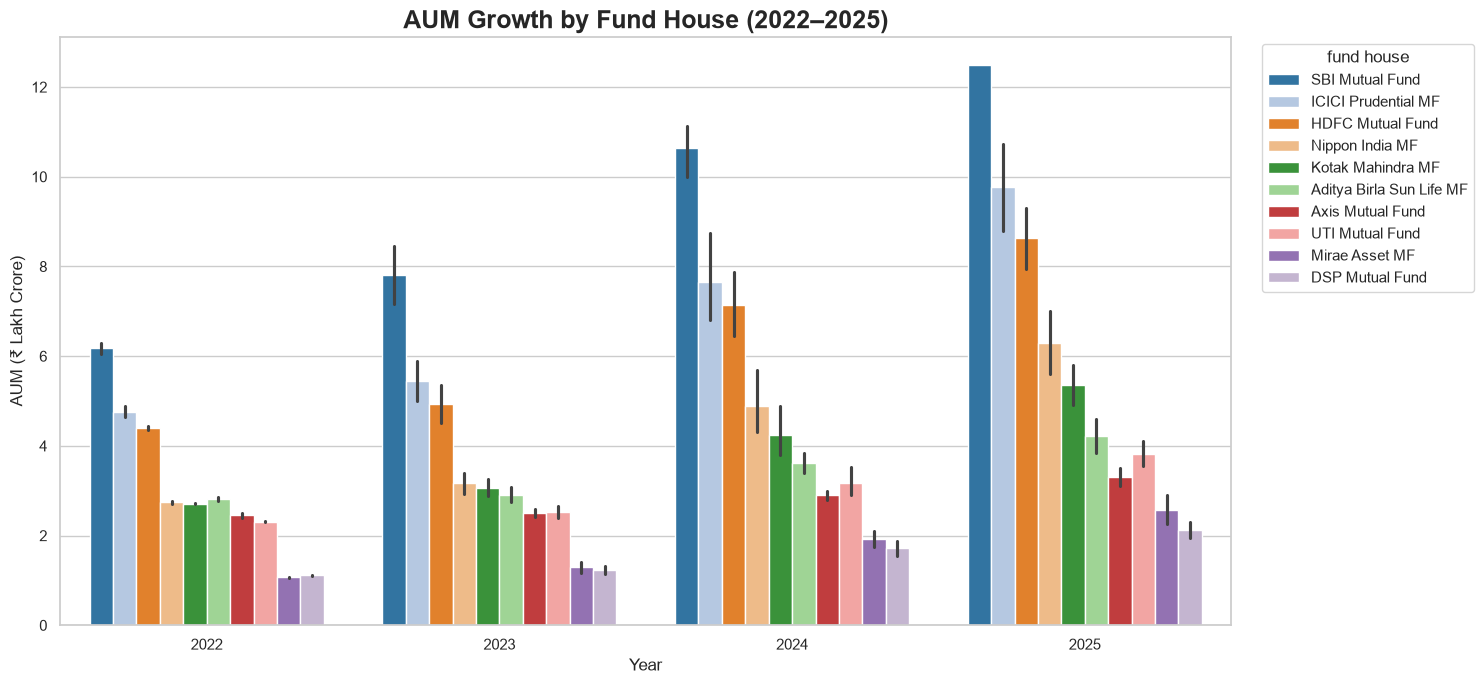

In [ ]:

# ------------------------ 
# Grouped Bar Chart
# ----------------------- 
plt.figure(figsize=(15,7))

ax_fig = sns.barplot(
    data=aum_df,
    x="Year",
    y="aum_lakh_crore",
    hue="fund_house",
    palette="tab20"
)
 

ax_fig.set_title(
    "AUM Growth by Fund House (2022–2025)",
    fontsize=18,
    weight="bold"
)
ax_fig.set_xlabel("Year")
ax_fig.set_ylabel("AUM (₹ Lakh Crore)")

ax_fig.legend(title="fund house", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


plt.savefig(
    os.path.join(chart_path, "task2_aum_growth_by_fund_house.png"),
    dpi=300,
    bbox_inches="tight"
)
print(" Chart saved successfully!")

 Chart saved successfully!


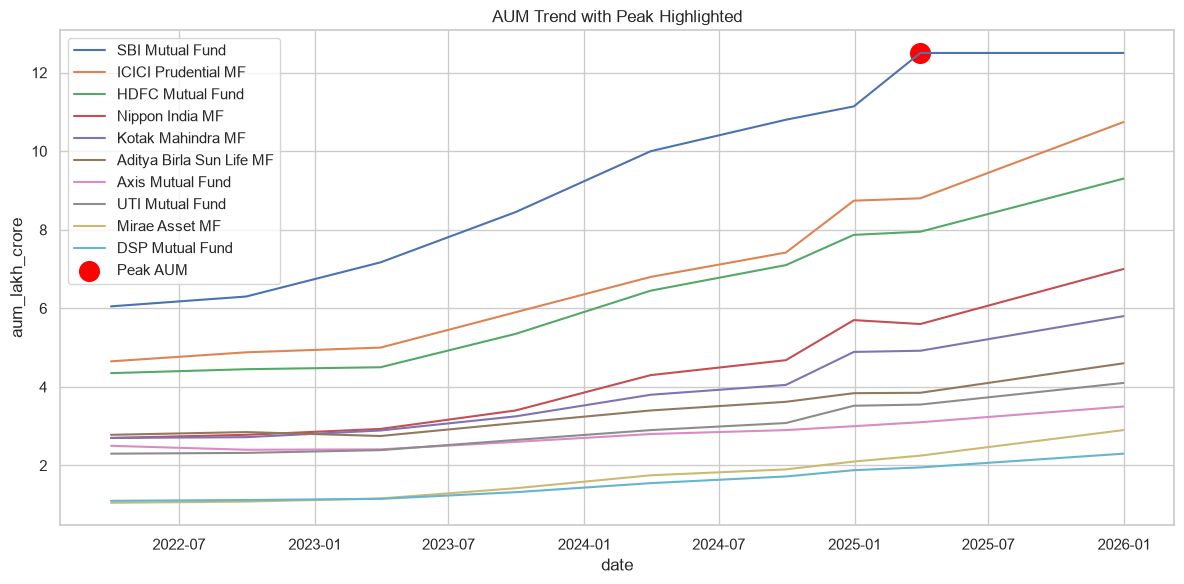

In [28]:
 

plt.figure(figsize=(12,6))

line_plot = sns.lineplot(
    data=aum_df,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

 
max_idx = aum_df["aum_lakh_crore"].idxmax()
peak = aum_df.loc[max_idx]

plt.scatter(
    peak["date"],
    peak["aum_lakh_crore"],
    color="red",
    s=200,
    label="Peak AUM"
)

plt.title("AUM Trend with Peak Highlighted")
plt.legend()
plt.tight_layout()
 

plt.savefig(
    os.path.join(chart_path, "task2_aum_line_trend.png"),
   dpi=300,
)

print(" Chart saved successfully!")




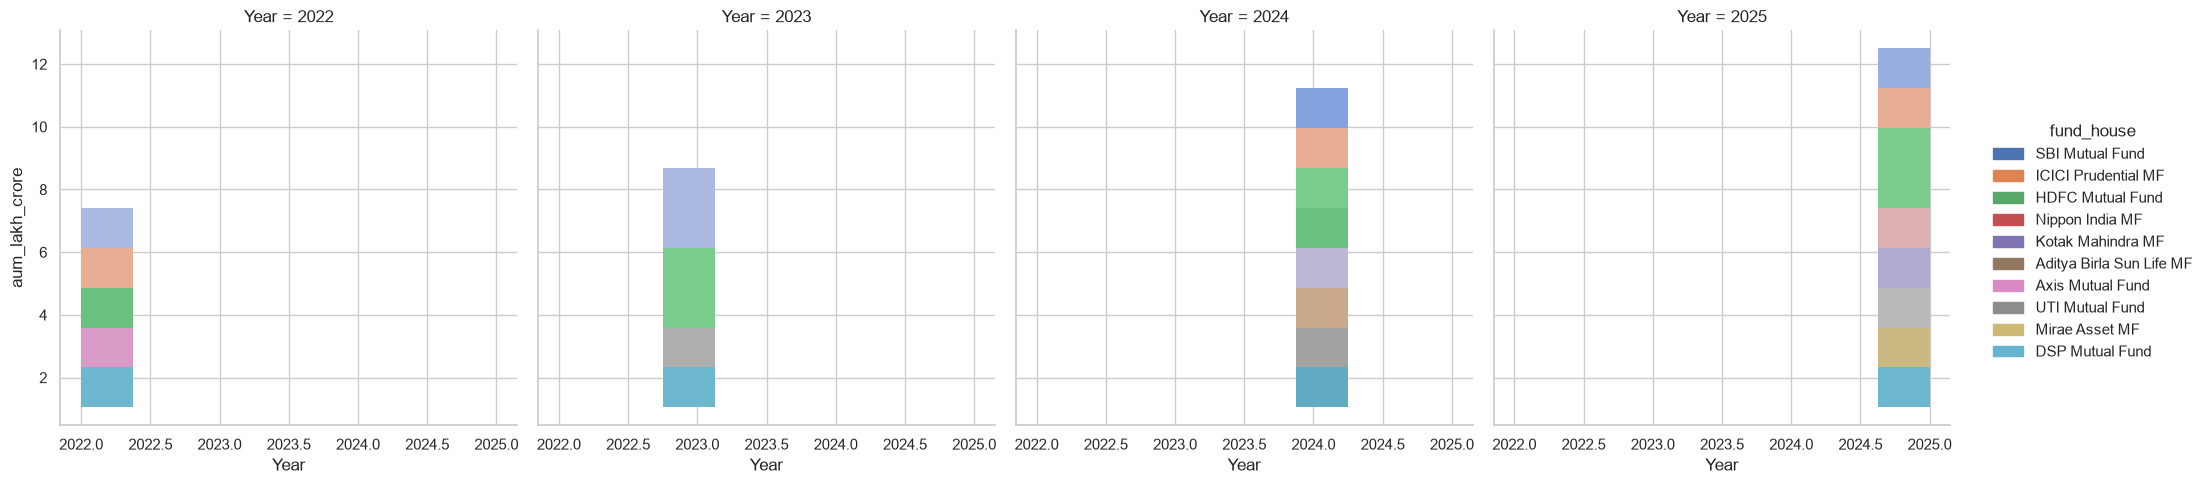

In [25]:

year_wise = sns.displot(data=aum_df, x="Year",y="aum_lakh_crore",hue="fund_house",col="Year")


year_wise.savefig(os.path.join(chart_path,"task2_year_wise_plot.png"),dpi=300,
    bbox_inches="tight")
print(" Chart saved successfully!")

In [1]:
import random

sample_df = aum_df.sample(n=30)

fig = px.scatter(
    sample_df,
    x="date",
    y="aum_lakh_crore",
    color="fund_house",
    size="num_schemes",
    hover_data=[
        "fund_house",
        "date",
        "aum_lakh_crore",
        "num_schemes"
    ],
    title="Random AUM Exploration: Fund House vs Date vs Schemes",
    template="plotly_white"
)

# -----------------------------
# Improve layout
# -----------------------------
fig.update_layout(
    height=600,
    hovermode="closest"
)

fig.show()

 


fig.write_image(
    os.path.join(chart_path,"task2_random_aum_scatter.png"),
    width=1920,
    height=1080,
    scale=3
)
print(" Chart saved successfully!")

NameError: name 'aum_df' is not defined

# Task 3: Monthly SIP Inflow Trend Analysis (2022–2025)

## Objective
Analyze the monthly Systematic Investment Plan (SIP) inflows from January 2022 to December 2025.

## Business Questions
- How have SIP inflows changed over time?
- Which month recorded the highest SIP inflow?
- How has investor participation evolved?

In [32]:
sip = pd.read_csv(
    r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\04_monthly_sip_inflows.csv"
)

sip.head(2)

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.1,4.80,NaN
1,2022-02,11438,4.93,8.2,4.85,NaN


In [33]:
# ----------------------------------------------------------
# Create Working Copy
# ----------------------------------------------------------

sip_df = sip.copy()

In [31]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [40]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

In [47]:
# ----------------------------------------------------------
# Find Maximum SIP Inflow
# ----------------------------------------------------------
 


max_idx = sip_df["sip_inflow_crore"].idxmax()
max_row = sip_df.loc[max_idx]

print("Highest SIP Inflow")
print(max_row)


Highest SIP Inflow
month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [ ]:
# --------------------- 
# Create Line Chart
# --------------------- 

fig_4 = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month":"Month",
        "sip_inflow_crore":"SIP Inflow (₹ Crore)"
    },
    template="plotly_white"
)

# ------------------------------- 
# Highlight Highest SIP Inflow
# ------------------------------- 

fig_4.add_trace(
    go.Scatter(
        x=[max_row["month"].to_pydatetime()],
        y=[max_row["sip_inflow_crore"]],
        mode="markers",
        marker=dict(
            color="red",
            size=14
        ),
        name="Highest SIP"
    )
)
# ------------ 
# Annotation
# ------------ 

fig_4.add_annotation(
    x=max_row["month"].to_pydatetime(),
    y=max_row["sip_inflow_crore"],
    text=f"₹{max_row['sip_inflow_crore']:,} Cr<br>{max_row['month'].strftime('%b %Y')}",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.2,
    arrowwidth=2,
    ax=-60,
    ay=-80,
    bgcolor="yellow",
    bordercolor="black"
)

 
fig_4.update_layout(
    height=650,
    title_x=0.5,
    hovermode="x unified"
)


fig_4.write_image(os.path.join(chart_path,"task3_sip_inflow.png"),
    width=1800,
    height=900,
    scale=2
)

fig_4.show()
print("chart save successfully")

chart save successfully


# Task 4: Category-wise Net Inflow Heatmap

## Objective

Analyze monthly net inflows across mutual fund categories to identify
which categories consistently attract investor money and whether any
seasonal investment patterns exist.

## Business Questions

- Which category receives the highest inflows?
- Which months have the strongest inflows?
- Are investors shifting towards particular categories?

In [63]:
category = pd.read_csv(
    r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\05_category_inflows.csv"
)

In [65]:
# ----------------------------------------------------------
# Create Working Copy
# ----------------------------------------------------------

category_df = category.copy()

In [66]:
category_df.head(3)

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0


In [ ]:
 
# Data Cleaning
 

category_df["month"] = pd.to_datetime(category_df["month"])

# Month Label
category_df["Month"] = category_df["month"].dt.strftime("%b-%Y")

chart successfull upload


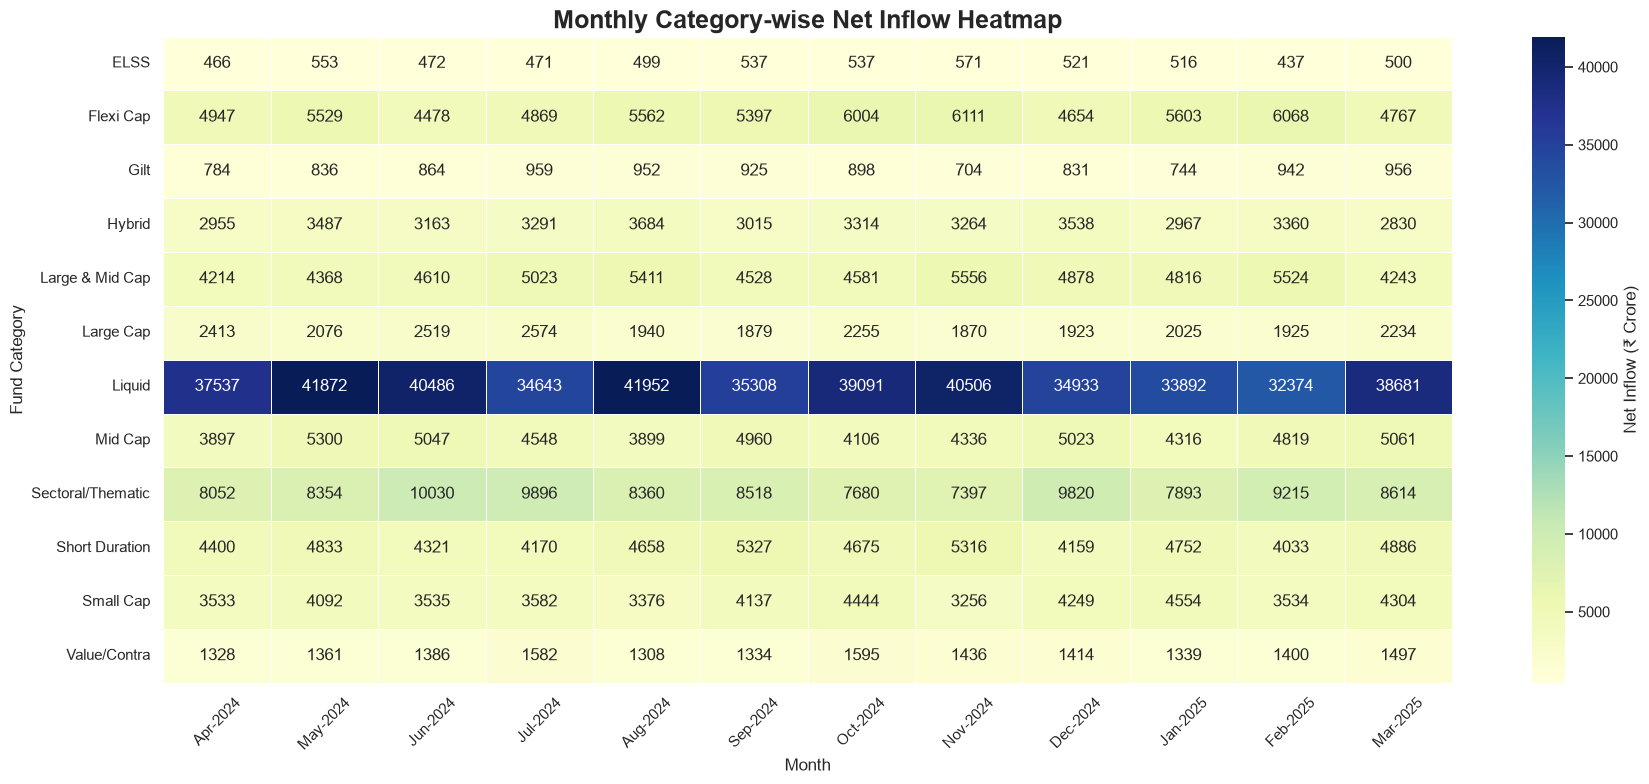

In [ ]:
heatmap_data = category_df.pivot(
    index="category",
    columns="Month",
    values="net_inflow_crore"
)

# Keep months in chronological order
heatmap_data = heatmap_data[
    category_df.sort_values("month")["Month"].unique()
]

# -------------- 
# Heatmap Plot
# --------------

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label":"Net Inflow (₹ Crore)"}
)

plt.title(
    "Monthly Category-wise Net Inflow Heatmap",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()


plt.savefig(os.path.join(chart_path,"task4_heatmap.png"),
dpi = 300)

print("chart successfull upload")

# Task 5: Investor Demographics
     
# Investor demographics

1. Age group distribution pie chart
2. SIP amount box plot by age group
3. Gender split

In [81]:
investor = pd.read_csv(
    r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\08_investor_transactions.csv"
)

investor.head(2)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified


In [82]:
# ==========================================================
# Task 5 : Investor Demographics
# ==========================================================

demo_df = investor.copy()

# Convert Date
demo_df["transaction_date"] = pd.to_datetime(demo_df["transaction_date"])

# Keep only SIP transactions
sip_demo = demo_df[
    demo_df["transaction_type"]=="SIP"
].copy()

Age Group Distribution

In [90]:
age_count = (
    sip_demo["age_group"]
    .value_counts()
    .reset_index()
)

age_count.columns = ["Age Group","Investors"]

fig = px.pie(
    age_count,
    names="Age Group",
    values="Investors",
    hole=0.45,
    title="Age Group Distribution of SIP Investors"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    title_x=0.5
)


 
fig.write_image(
    os.path.join(chart_path,"task5_age_distribution.png"),
    width=1600,
    height=900,
    scale=2
)
fig.show()

SIP Amount Box Plot

In [91]:
fig = px.box(
    sip_demo,
    x="age_group",
    y="amount_inr",
    color="age_group",
    points="outliers",
    title="SIP Amount Distribution by Age Group"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Age Group",
    yaxis_title="SIP Amount (₹)"
)
fig.write_image(
    os.path.join(chart_path,"task5_age_distribution.png"),
    width=1600,
    height=900,
    scale=2
)

fig.write_image(
    os.path.join(chart_path,"task5_Sip.png"),
    width=1600,
    height=900,
    scale=2
)
fig.show()

Gender Split

In [89]:
gender = (
    sip_demo["gender"]
    .value_counts()
    .reset_index()
)

gender.columns=["Gender","Count"]

fig = px.pie(
    gender,
    names="Gender",
    values="Count",
    hole=0.5,
    title="Gender Distribution of SIP Investors"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    title_x=0.5
)


fig.write_image(
    os.path.join(chart_path,"task5_gender_split.png"),
    width=1600,
    height=900,
    scale=2
)
fig.show()

In [93]:
sip_demo.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [95]:
avg = sip_demo.groupby("age_group")["amount_inr"].mean().reset_index()

fig = px.bar(
    avg,
    x="age_group",
    y="amount_inr",
    color="amount_inr",
    title="Average SIP Amount by Age Group",
    text_auto=".0f"
)

fig.show()


 Task 6 : SIP Amount by State
 

In [ ]:
# Use only SIP transactions
geo_df = sip_demo.copy()

# Aggregate SIP amount by state
state_sip = (
    geo_df.groupby("state")["amount_inr"]
    .sum()
    .reset_index()
    .sort_values("amount_inr", ascending=True)
)

# Horizontal Bar Chart
fig = px.bar(
    state_sip,
    x="amount_inr",
    y="state",
    orientation="h",
    color="amount_inr",
    color_continuous_scale="Viridis",
    title="Total SIP Amount by State",
    labels={
        "amount_inr": "Total SIP Amount (₹)",
        "state": "State"
    },
    text_auto=".2s"
)

fig.update_layout(
    title_x=0.5,
    height=700,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

 
fig.write_image(
    os.path.join(chart_path, "task6_state_sip.png"),
    width=1800,
    height=900,
    scale=2
)

T30 vs B30 City Tier 

In [ ]:
tier_data = (
    geo_df["city_tier"]
    .value_counts()
    .reset_index()
)

tier_data.columns = ["City Tier", "Investors"]

fig = px.pie(
    tier_data,
    names="City Tier",
    values="Investors",
    hole=0.55,
    title="T30 vs B30 City Tier Distribution"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    title_x=0.5
)

fig.show()

 

fig.write_image(
    os.path.join(chart_path, "task6_city_tier.png"),
    width=1600,
    height=900,
    scale=2
)

In [108]:
city_data = (
    geo_df.groupby("city")["amount_inr"]
    .sum()
    .reset_index()
    .sort_values("amount_inr", ascending=False)
    .head(10)
)

fig = px.bar(
    city_data,
    x="city",
    y="amount_inr",
    color="amount_inr",
    text_auto=".2s",
    title="Top 10 Cities by SIP Amount"
)

fig.update_layout(title_x=0.5)

fig.show()
fig.write_image(
    os.path.join(chart_path, "task6_top6_city.png"),
    width=1600,
    height=900,
    scale=2
)

In [107]:
investor_count = (
    geo_df.groupby("state")["investor_id"]
    .nunique()
    .reset_index()
    .sort_values("investor_id", ascending=False)
)

fig = px.bar(
    investor_count,
    x="investor_id",
    y="state",
    orientation="h",
    color="investor_id",
    title="Unique SIP Investors by State"
)

fig.update_layout(title_x=0.5)

fig.show()

fig.write_image(
    os.path.join(chart_path, "task6_Sip_by_state.png"),
    width=1600,
    height=900,
    scale=2
)

# Task 7: Mutual Fund Folio Growth Analysis

## Objective

Analyze the growth of mutual fund folios between 2022 and 2025.

# Business Questions

- How rapidly has the number of folios grown?
- What is the growth trend?
- Which period experienced the highest increase?

In [110]:
folio = pd.read_csv(
    r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\06_industry_folio_count.csv"
)

folio.head(3)

 

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38


In [ ]:
# ----------------------------------------------------------
# create working Copy
# ----------------------------------------------------------

folio_df = folio.copy()

In [113]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

In [118]:
 

fig = px.line(
    folio_df,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth of Mutual Fund Folios (2022–2025)",
    labels={
        "month":"Month",
        "total_folios_crore":"Total Folios (Crore)"
    },
    template="plotly_white"
)

 

fig.add_annotation(
    x=folio_df.iloc[0]["month"].strftime("%Y-%m-%d"),
    y=folio_df.iloc[0]["total_folios_crore"],
    text=f"Start<br>{folio_df.iloc[0]['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=-50,
    ay=-60,
    bgcolor="lightgreen"
)

 

fig.add_annotation(
    x=folio_df.iloc[-1]["month"].strftime("%Y-%m-%d"),
    y=folio_df.iloc[-1]["total_folios_crore"],
    text=f"End<br>{folio_df.iloc[-1]['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=50,
    ay=-60,
    bgcolor="gold"
)

 
growth = (
    (
        folio_df.iloc[-1]["total_folios_crore"] -
        folio_df.iloc[0]["total_folios_crore"]
    )
    /
    folio_df.iloc[0]["total_folios_crore"]
) * 100

fig.add_annotation(
    x=folio_df.iloc[len(folio_df)//2]["month"].strftime("%Y-%m-%d"),
    y=folio_df["total_folios_crore"].max(),
    text=f"Overall Growth: {growth:.1f}%",
    showarrow=False,
    bgcolor="lightblue",
    font=dict(size=14)
)

fig.update_layout(
    title_x=0.5,
    height=650,
    hovermode="x unified"
)

fig.show()


fig.write_image(
    os.path.join(chart_path, "task7_folio_growth.png"),
    width=1800,
    height=900,
    scale=2
)


In [123]:
fig = px.line(
    folio_df,
    x="month",
    y=[
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore"
    ],
    markers=True,
    title="Category-wise Folio Growth",
    template="plotly_white"
)

fig.update_layout(
    title_x=0.5,
    hovermode="x unified"
)

fig.show()
fig.write_image(
    os.path.join(chart_path, "task7_Category_wise.png"),
    width=1800,
    height=900,
    scale=2
)

In [122]:
folio_df["monthly_growth"] = (
    folio_df["total_folios_crore"].diff()
)

fig = px.bar(
    folio_df,
    x="month",
    y="monthly_growth",
    color="monthly_growth",
    title="Monthly Increase in Mutual Fund Folios",
    template="plotly_white"
)

fig.update_layout(title_x=0.5)

fig.show()

fig.write_image(
    os.path.join(chart_path, "task7_Montly_inc.png"),
    width=1800,
    height=900,
    scale=2
)

# Task 8: NAV Return Correlation Matrix

# Objective

Analyze the relationship between the daily returns of selected mutual fund schemes.

#  Assignment target

- Which funds move together?
- Which funds are highly correlated?
- Are there any diversification opportunities?

In [126]:
fund_master = pd.read_csv(
    r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\01_fund_master.csv"
)

fund_master.head(2)

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01


In [ ]:
# ----------------------------------------------------------
# create working Copies
# ----------------------------------------------------------

nav_df_8 = nav.copy()
fund_df_8 = fund_master.copy()

In [134]:
nav_df_8["date"] = pd.to_datetime(nav_df_8["date"])

In [135]:

nav_df_8 = nav_df_8.merge(
    fund_df_8[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

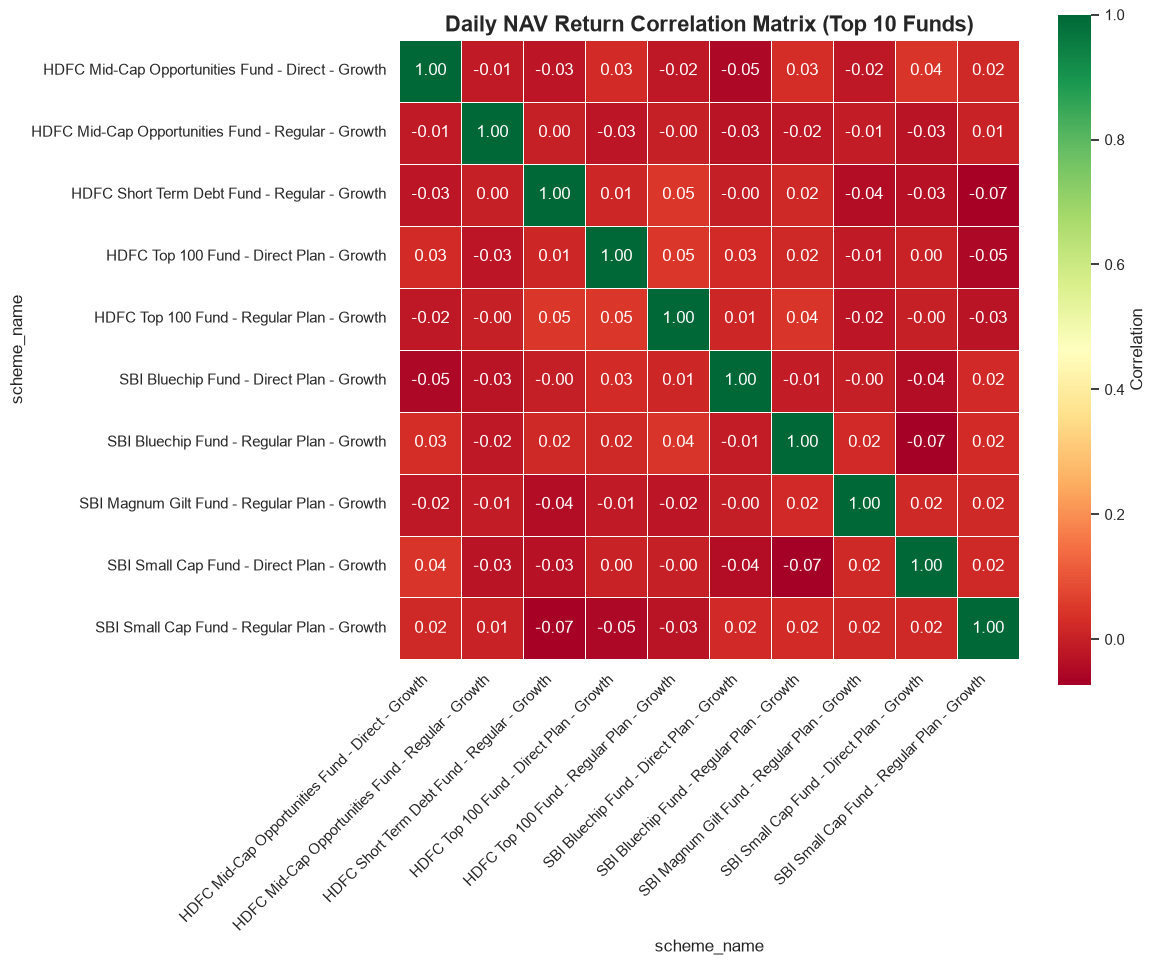

In [138]:
selected_funds = (
    nav_df_8["scheme_name"]
    .drop_duplicates()
    .head(10)
)

nav_selected = nav_df_8[
    nav_df_8["scheme_name"].isin(selected_funds)
].copy()


pivot_nav = nav_selected.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)
daily_returns = pivot_nav.pct_change().dropna()

 
# Correlation Matrix
 

corr_matrix = daily_returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label":"Correlation"}
)

plt.title(
    "Daily NAV Return Correlation Matrix (Top 10 Funds)",
    fontsize=16,
    fontweight="bold"
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(chart_path, "task8_nav_correlation.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Task 9: Sector Allocation Analysis

# Objective

Analyze the sector allocation across equity mutual funds to identify
which sectors receive the highest portfolio allocation.

# Business Questions

- Which sectors dominate equity portfolios?
- Which sectors receive the lowest allocation?
- How diversified are the portfolios?

In [142]:
portfolio = pd.read_csv(
    r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\09_portfolio_holdings.csv"
)

portfolio.head(2)

 

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31


In [ ]:
# ----------------------------------------------------------
# create working Copy
# ----------------------------------------------------------

portfolio_df = portfolio.copy()

In [144]:
sector_data = (
    portfolio_df
    .groupby("sector", as_index=False)["weight_pct"]
    .sum()
    .sort_values("weight_pct", ascending=False)
)


In [146]:
fig = px.pie(
    sector_data,
    names="sector",
    values="weight_pct",
    hole=0.55,
    title="Sector Allocation Across Equity Mutual Funds",
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label",
    hovertemplate="<b>%{label}</b><br>Weight: %{value:.2f}%<extra></extra>"
)

fig.update_layout(
    title_x=0.5,
    height=700,
    legend_title="Sector"
)

fig.show()

fig.write_image(
    os.path.join(chart_path, "task9_sector_donut.png"),
    width=1800,
    height=900,
    scale=2
)

In [148]:
top10 = sector_data.head(10)

fig = px.bar(
    top10,
    x="weight_pct",
    y="sector",
    orientation="h",
    color="weight_pct",
    color_continuous_scale="Viridis",
    text="weight_pct",
    title="Top 10 Sectors by Portfolio Weight"
)

fig.update_traces(texttemplate="%{text:.2f}%")

fig.update_layout(
    title_x=0.5,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

fig.write_image(
    os.path.join(chart_path, "task9_top10_sector.png"),
    width=1800,
    height=900,
    scale=2
)

# Key Exploratory Data Analysis (EDA) Findings

### Insight 1 – NAV Trend Analysis
Daily NAV values across the selected mutual fund schemes showed an overall upward trend from 2022 to 2025, with noticeable growth during the 2023 market rally and temporary declines during the 2024 market correction.
**Reference:** Task 1 – NAV Trend Analysis

---

### Insight 2 – AUM Growth
SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore and remaining the industry leader throughout the analysis period.
**Reference:** Task 2 – AUM Growth Analysis

---

### Insight 3 – SIP Inflows
Monthly SIP inflows increased steadily between 2022 and 2025, reaching an all-time high of **₹31,002 crore** in **December 2025**, reflecting strong retail investor participation.
**Reference:** Task 3 – SIP Inflow Trend

---

### Insight 4 – Category-wise Inflows
Flexi Cap, Mid Cap, Large Cap, and Large & Mid Cap funds consistently attracted higher monthly inflows compared to other mutual fund categories.
**Reference:** Task 4 – Category Inflow Heatmap

---

### Insight 5 – Investor Demographics
The majority of SIP investors belong to the **26–35** and **36–45** age groups, indicating that working professionals form the largest investor segment.
**Reference:** Task 5 – Investor Demographics

---

### Insight 6 – Geographic Distribution
Metro (T30) cities contributed a significant share of SIP investments, while several B30 cities also demonstrated increasing participation, indicating broader mutual fund adoption.
**Reference:** Task 6 – Geographic Distribution

---

### Insight 7 – Folio Growth
The total number of mutual fund folios increased significantly during the study period, highlighting sustained expansion in the Indian mutual fund industry.
**Reference:** Task 7 – Folio Count Growth

---

### Insight 8 – Fund Correlation
Most large-cap equity funds exhibited strong positive correlations in daily returns, suggesting similar market behaviour and investment strategies.
**Reference:** Task 8 – NAV Return Correlation Matrix

---

### Insight 9 – Sector Allocation
Financial Services, Information Technology, and Banking represented the largest portfolio allocations across equity mutual funds, reflecting their importance in the Indian equity market.
**Reference:** Task 9 – Sector Allocation Donut Chart

---

### Insight 10 – Overall Industry Growth
The combined analysis of NAV trends, SIP inflows, AUM growth, folio counts, and investor participation indicates healthy and sustained growth in India's mutual fund industry from 2022 to 2025.
**Reference:** Overall Dashboard